<a href="https://colab.research.google.com/github/ahmed8809/FlyRank_intern/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

The action queue separates two ideas:

1. **Archetype** = a descriptive profile of observed performance/freshness signals.
2. **Action priority** = a practical ranking used to decide which items a human should inspect first.

### Reason codes

- `R1_STALE` — content is at least 90 days stale.
- `R2_VISIBILITY` — content has at least 100 observed impressions.
- `R3_HIGH_VISIBILITY` — content has at least 1,000 observed impressions.
- `R4_VERY_STALE_LOW_DEMAND` — content is at least 180 days stale but has fewer than 100 impressions.
- `R5_ESTABLISHED` — item belongs to the more visible/established archetype.
- `R6_POSITION_MISSING` — search-position information is unavailable.
- `R7_LOW_CLUSTER_CERTAINTY` — the item is close to the cluster boundary.

The thresholds are **operational triage rules**, not validated causal cutoffs.

In [1]:
from pathlib import Path
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 42
SNAPSHOT_MONTH = "2026-03"

ROOT = Path.cwd()
OUT_DIR = ROOT / "work" / "outputs"
FIG_DIR = ROOT / "work" / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_ctr",
    "gsc_avg_position",
    "stale_days",
    "position_missing",
]

print("Working directory:", ROOT)
print("Output directory:", OUT_DIR)
print("Figure directory:", FIG_DIR)

Working directory: /content
Output directory: /content/work/outputs
Figure directory: /content/work/figures


## Load the validated March 2026 feature population

The feature construction follows the Week-5 setup.

We use:

- March 2026 Search Console performance;
- content freshness;
- the six structured features used for clustering.

Identifiers are used only for grouping and reporting, not as model features.

In [3]:
import duckdb
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(
    f"CREATE SECRET (TYPE huggingface, TOKEN {HF_TOKEN})"
)

rel = "hf://datasets/FlyRank/internship-warehouse"

print("Connection ready")

Connection ready


In [4]:
# Build the March 2026 content-level feature table.

march_sql = f"""
WITH march AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,

        SUM(COALESCE(f.gsc_impressions, 0)) AS gsc_impressions,
        SUM(COALESCE(f.gsc_clicks, 0)) AS gsc_clicks,

        AVG(f.gsc_avg_position) AS gsc_avg_position,

        MAX(
            CASE
                WHEN f.gsc_avg_position IS NULL THEN 1
                ELSE 0
            END
        ) AS position_missing,

        MAX(f.report_date) AS snapshot_date

    FROM read_parquet(
        '{REL}/fact_content_daily_performance/month=2026-03/*.parquet'
    ) f

    WHERE f.gsc_data_available IS TRUE

    GROUP BY
        f.client_hash_id,
        f.content_hash_id
),

content AS (
    SELECT
        client_hash_id,
        content_hash_id,
        content_updated_date

    FROM read_parquet(
        '{REL}/dim_content.parquet'
    )
)

SELECT
    m.client_hash_id,
    m.content_hash_id,

    m.gsc_impressions,
    m.gsc_clicks,

    CASE
        WHEN m.gsc_impressions > 0
        THEN m.gsc_clicks::DOUBLE / m.gsc_impressions
        ELSE 0
    END AS gsc_ctr,

    m.gsc_avg_position,
    m.position_missing,

    DATE_DIFF(
        'day',
        c.content_updated_date,
        m.snapshot_date
    ) AS stale_days

FROM march m

INNER JOIN content c
    ON m.client_hash_id = c.client_hash_id
    AND m.content_hash_id = c.content_hash_id

WHERE c.content_updated_date IS NOT NULL
  AND c.content_updated_date <= m.snapshot_date
"""

march_features = con.sql(march_sql).df()

# Basic cleaning / type conversion
for col in FEATURES:
    march_features[col] = pd.to_numeric(
        march_features[col],
        errors="coerce"
    )

march_features["position_missing"] = (
    march_features["position_missing"]
    .fillna(1)
    .astype(int)
)

# Safety checks
assert march_features["stale_days"].notna().all()
assert (march_features["stale_days"] >= 0).all()

print(f"Rows: {len(march_features):,}")
print(f"Clients: {march_features['client_hash_id'].nunique():,}")

display(
    march_features[FEATURES]
    .describe()
    .round(3)
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 27,886
Clients: 33


,gsc_impressions,gsc_clicks,gsc_ctr,gsc_avg_position,stale_days,position_missing
count,27886.000,27886.000,27886.000,27886.000,27886.000,27886.0
mean,1237.226,2.804,0.003,14.922,38.484,0.0
std,3686.806,11.808,0.028,15.137,27.815,0.0
min,1.000,0.000,0.000,0.000,0.000,0.0
25%,39.000,0.000,0.000,5.141,34.000,0.0
50%,274.000,0.000,0.000,8.580,34.000,0.0
75%,1040.750,1.000,0.002,19.864,34.000,0.0
max,139417.000,387.000,1.000,139.889,303.000,0.0


## Refit the final two-archetype clustering model

Week 6 validated the two-cluster approach using grouped client-held-out validation.

For the final playbook, we refit the same two-cluster setup on the March snapshot so that the resulting archetype assignment covers the full snapshot population used by the action queue.

This is a **final descriptive fit after validation**, not a replacement for the Week-6 validation result.

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = march_features.copy()

# Same structured feature set used in W05.
X_raw = df[FEATURES].copy()

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# Final two-cluster model
kmeans = KMeans(
    n_clusters=2,
    random_state=SEED,
    n_init=20
)

df["cluster"] = kmeans.fit_predict(X)

# Distance to each cluster center
distances = kmeans.transform(X)

sorted_distances = np.sort(distances, axis=1)

df["cluster_distance"] = sorted_distances[:, 0]

# Difference between closest and second-closest cluster.
df["cluster_margin"] = (
    sorted_distances[:, 1]
    - sorted_distances[:, 0]
)

# Confidence proxy based on relative margin.
df["cluster_confidence_proxy"] = (
    df["cluster_margin"]
    / (sorted_distances[:, 1] + 1e-9)
)

# Descriptive full-snapshot silhouette.
full_silhouette = silhouette_score(
    X,
    df["cluster"]
)

profile = (
    df.groupby("cluster")
      .agg(
          n=("content_hash_id", "size"),
          impressions_median=("gsc_impressions", "median"),
          impressions_mean=("gsc_impressions", "mean"),
          clicks_median=("gsc_clicks", "median"),
          ctr_median=("gsc_ctr", "median"),
          position_median=("gsc_avg_position", "median"),
          stale_days_median=("stale_days", "median"),
          stale_days_mean=("stale_days", "mean"),
      )
      .sort_index()
)

print(f"Full March descriptive silhouette: {full_silhouette:.4f}")

display(profile.round(3))

Full March descriptive silhouette: 0.8056


,n,impressions_median,impressions_mean,clicks_median,ctr_median,position_median,stale_days_median,stale_days_mean
cluster,,,,,,,,
0,27465,263.0,908.248,0.0,0.000,8.661,34.0,38.505
1,421,19024.0,22698.895,57.0,0.003,4.087,34.0,37.074


In [6]:
# Give the anonymous cluster IDs interpretable names based on their measured profiles.

stale_cluster = profile["stale_days_median"].idxmax()
visible_cluster = profile["impressions_median"].idxmax()

if stale_cluster == visible_cluster:
    raise ValueError(
        "The two clusters do not separate into distinct stale/visible profiles."
    )

archetype_map = {
    stale_cluster: "Stale Low-Demand",
    visible_cluster: "Visible / Established",
}

df["archetype"] = df["cluster"].map(archetype_map)

print("Archetype mapping:")
for cluster_id, name in sorted(archetype_map.items()):
    print(f"  Cluster {cluster_id} -> {name}")

print("\nArchetype counts:")
display(
    df["archetype"]
      .value_counts()
      .rename("pages")
      .to_frame()
)

Archetype mapping:
  Cluster 0 -> Stale Low-Demand
  Cluster 1 -> Visible / Established

Archetype counts:


,pages
archetype,
Stale Low-Demand,27465
Visible / Established,421


## Build the action-priority queue

The score below is intentionally transparent.

It combines:

- relative content staleness;
- relative observed search visibility;
- a small additional priority bonus when an item is both stale and meaningfully visible.

It is **not** a probability of uplift, ROI, or causal impact.

In [7]:
q = df.copy()

# Percentile-based components make the score easier to compare across scales.
q["staleness_pctile"] = (
    q["stale_days"]
    .rank(pct=True, method="average")
)

q["visibility_pctile"] = (
    np.log1p(q["gsc_impressions"])
    .rank(pct=True, method="average")
)

# Operational thresholds
q["stale_90"] = q["stale_days"] >= 90
q["very_stale"] = q["stale_days"] >= 180

q["meaningful_visibility"] = (
    q["gsc_impressions"] >= 100
)

q["high_visibility"] = (
    q["gsc_impressions"] >= 1000
)

# Boundary / uncertainty flags
q["low_cluster_confidence"] = (
    q["cluster_confidence_proxy"] < 0.10
)


def build_reason_codes(row):
    codes = []

    if row["stale_90"]:
        codes.append("R1_STALE")

    if row["meaningful_visibility"]:
        codes.append("R2_VISIBILITY")

    if row["high_visibility"]:
        codes.append("R3_HIGH_VISIBILITY")

    if (
        row["very_stale"]
        and not row["meaningful_visibility"]
    ):
        codes.append("R4_VERY_STALE_LOW_DEMAND")

    if row["archetype"] == "Visible / Established":
        codes.append("R5_ESTABLISHED")

    if row["position_missing"] == 1:
        codes.append("R6_POSITION_MISSING")

    if row["low_cluster_confidence"]:
        codes.append("R7_LOW_CLUSTER_CERTAINTY")

    return ";".join(codes)


q["reason_code"] = q.apply(
    build_reason_codes,
    axis=1
)


# Human-review priority score
q["review_priority_score"] = (
    0.60 * q["staleness_pctile"]
    + 0.40 * q["visibility_pctile"]
)

# Small bonus for stale content that already has measurable visibility.
q.loc[
    q["stale_90"] & q["meaningful_visibility"],
    "review_priority_score"
] += 0.10

q["review_priority_score"] = (
    q["review_priority_score"]
    .clip(upper=1.0)
)

In [8]:
# Map queue items to recommended actions.

q["action"] = np.select(
    [
        q["low_cluster_confidence"],

        q["position_missing"] & q["stale_90"],

        q["stale_90"] & q["meaningful_visibility"],

        q["very_stale"] & ~q["meaningful_visibility"],

        q["archetype"].eq("Visible / Established"),
    ],

    [
        "manual review — boundary case",

        "manual review — missing position",

        "review for refresh",

        "diagnose before refresh investment",

        "monitor / maintain",
    ],

    default="monitor / maintain"
)


q["value_tier"] = np.select(
    [
        q["gsc_impressions"] >= 1000,
        q["gsc_impressions"] >= 100,
    ],

    [
        "higher observed visibility",
        "meaningful observed visibility",
    ],

    default="low observed visibility"
)


# Everything remains human-reviewed.
q["human_review_required"] = True


# Sort from highest review priority to lowest.
q = q.sort_values(
    [
        "review_priority_score",
        "stale_days",
        "gsc_impressions",
    ],
    ascending=False
).reset_index(drop=True)

q["rank"] = np.arange(1, len(q) + 1)

queue_cols = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "cluster",
    "archetype",
    "action",
    "review_priority_score",
    "reason_code",
    "human_review_required",
    "value_tier",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_ctr",
    "gsc_avg_position",
    "position_missing",
    "stale_days",
    "cluster_confidence_proxy",
]

action_queue = q[queue_cols].copy()

display(
    action_queue.head(25).round(4)
)

,rank,client_hash_id,content_hash_id,cluster,archetype,action,review_priority_score,reason_code,human_review_required,value_tier,gsc_impressions,gsc_clicks,gsc_ctr,gsc_avg_position,position_missing,stale_days,cluster_confidence_proxy
0,1,client_c182d11e4862a37d,content_42ce26be1ec6be00,0,Stale Low-Demand,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY,True,higher observed visibility,4411.0,6.0,0.0014,4.2626,0,264,0.2533
1,2,client_c182d11e4862a37d,content_5120dcbbb086843d,0,Stale Low-Demand,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY,True,higher observed visibility,1429.0,0.0,0.0000,6.3212,0,247,0.3282
2,3,client_c182d11e4862a37d,content_bea86ce3455100b0,0,Stale Low-Demand,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY,True,higher observed visibility,3670.0,1.0,0.0003,6.5558,0,232,0.3302
3,4,client_157ffe4d4a595515,content_19daa2f24df1882d,0,Stale Low-Demand,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY,True,higher observed visibility,4968.0,7.0,0.0014,11.6710,0,176,0.4176
4,5,client_3ffa76342f366962,content_25aac3e5439711c6,0,Stale Low-Demand,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY,True,higher observed visibility,1327.0,12.0,0.0090,7.2909,0,141,0.5479
5,6,client_20259bd6705d81d4,content_097459d155cccb26,1,Visible / Established,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY;R5_E...,True,higher observed visibility,37930.0,55.0,0.0015,17.5507,0,124,0.5326
6,7,client_20259bd6705d81d4,content_f2df5a8a9057783e,1,Visible / Established,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY;R5_E...,True,higher observed visibility,35980.0,110.0,0.0031,15.5429,0,124,0.5675
7,8,client_20259bd6705d81d4,content_ac4e2d9d3bbb06de,1,Visible / Established,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY;R5_E...,True,higher observed visibility,33348.0,26.0,0.0008,23.3278,0,124,0.4044
8,9,client_20259bd6705d81d4,content_66d1fffc91f4f029,1,Visible / Established,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY;R5_E...,True,higher observed visibility,31038.0,52.0,0.0017,15.2169,0,124,0.5730
9,10,client_20259bd6705d81d4,content_b956947c822af734,1,Visible / Established,manual review — boundary case,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY;R5_E...,True,higher observed visibility,22502.0,7.0,0.0003,36.4845,0,124,0.0597


In [9]:
print("Action counts:")
display(
    action_queue["action"]
    .value_counts()
    .rename("pages")
    .to_frame()
)

print("\nArchetype × action:")
display(
    pd.crosstab(
        action_queue["archetype"],
        action_queue["action"]
    )
)

print("\nTop human-review candidates:")

review_actions = [
    "review for refresh",
    "diagnose before refresh investment",
    "manual review — boundary case",
    "manual review — missing position",
]

top_review = action_queue[
    action_queue["action"].isin(review_actions)
].head(20)

display(top_review.round(4))

Action counts:


,pages
action,
monitor / maintain,27451
diagnose before refresh investment,194
review for refresh,141
manual review — boundary case,100



Archetype × action:


action,diagnose before refresh investment,manual review — boundary case,monitor / maintain,review for refresh
archetype,,,,
Stale Low-Demand,194,65,27077,129
Visible / Established,0,35,374,12



Top human-review candidates:


,rank,client_hash_id,content_hash_id,cluster,archetype,action,review_priority_score,reason_code,human_review_required,value_tier,gsc_impressions,gsc_clicks,gsc_ctr,gsc_avg_position,position_missing,stale_days,cluster_confidence_proxy
0,1,client_c182d11e4862a37d,content_42ce26be1ec6be00,0,Stale Low-Demand,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY,True,higher observed visibility,4411.0,6.0,0.0014,4.2626,0,264,0.2533
1,2,client_c182d11e4862a37d,content_5120dcbbb086843d,0,Stale Low-Demand,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY,True,higher observed visibility,1429.0,0.0,0.0000,6.3212,0,247,0.3282
2,3,client_c182d11e4862a37d,content_bea86ce3455100b0,0,Stale Low-Demand,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY,True,higher observed visibility,3670.0,1.0,0.0003,6.5558,0,232,0.3302
3,4,client_157ffe4d4a595515,content_19daa2f24df1882d,0,Stale Low-Demand,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY,True,higher observed visibility,4968.0,7.0,0.0014,11.6710,0,176,0.4176
4,5,client_3ffa76342f366962,content_25aac3e5439711c6,0,Stale Low-Demand,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY,True,higher observed visibility,1327.0,12.0,0.0090,7.2909,0,141,0.5479
5,6,client_20259bd6705d81d4,content_097459d155cccb26,1,Visible / Established,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY;R5_E...,True,higher observed visibility,37930.0,55.0,0.0015,17.5507,0,124,0.5326
6,7,client_20259bd6705d81d4,content_f2df5a8a9057783e,1,Visible / Established,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY;R5_E...,True,higher observed visibility,35980.0,110.0,0.0031,15.5429,0,124,0.5675
7,8,client_20259bd6705d81d4,content_ac4e2d9d3bbb06de,1,Visible / Established,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY;R5_E...,True,higher observed visibility,33348.0,26.0,0.0008,23.3278,0,124,0.4044
8,9,client_20259bd6705d81d4,content_66d1fffc91f4f029,1,Visible / Established,review for refresh,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY;R5_E...,True,higher observed visibility,31038.0,52.0,0.0017,15.2169,0,124,0.5730
9,10,client_20259bd6705d81d4,content_b956947c822af734,1,Visible / Established,manual review — boundary case,1.0,R1_STALE;R2_VISIBILITY;R3_HIGH_VISIBILITY;R5_E...,True,higher observed visibility,22502.0,7.0,0.0003,36.4845,0,124,0.0597


## Archetype → action mapping

| Archetype / state | Default action | Interpretation |
|---|---|---|
| Stale Low-Demand + meaningful visibility | Review for refresh | Old content with measurable observed exposure |
| Stale Low-Demand + very low demand | Diagnose before refresh investment | Content is old, but evidence of search exposure is weak |
| Visible / Established + not stale | Monitor / maintain | Current observed profile does not create a strong refresh signal |
| Missing position information | Manual review | Important search evidence is unavailable |
| Low cluster certainty | Manual review | Archetype assignment should not drive the decision alone |

These actions are recommendations for **human review**, not automated production actions.

## 2. Intended use and limits

### Intended use

The playbook is intended for content/SEO analysts who need a practical way to triage a large content inventory.

It can be used to:

- identify pages that deserve review first;
- make the reason for review explicit;
- separate likely maintenance candidates from potential refresh candidates;
- prioritize limited editorial capacity.

### Limits

1. The archetypes are descriptive performance profiles, not semantic content categories.
2. The final archetype fit uses the March 2026 snapshot after the Week-6 validation was completed.
3. The Week-6 validation used a client-grouped holdout, but this does not guarantee future stability.
4. The rare stale/low-demand archetype is much smaller than the established group and should therefore be interpreted cautiously.
5. The queue thresholds are operational heuristics, not causal thresholds.
6. Search impressions are an exposure proxy, not a direct measure of business value.
7. This dataset does not provide the article text or full editorial context.
8. The model cannot determine content quality, factual accuracy, topical relevance, search intent match, revenue importance, or strategic importance.
9. Observational freshness/refresh relationships may be affected by selection and survivorship bias.

## 3. Human review + the no-go list

### Human review rules

Every queue item requires human review before action.

The reviewer should check:

- whether the topic and search intent are still relevant;
- whether facts, dates, prices, products, or claims need updating;
- whether the page has strategic, brand, referral, or business value not represented in the dataset;
- whether another explanation exists for the observed performance pattern;
- whether the recommended action is worth its editorial effort;
- whether the archetype assignment is uncertain;
- whether recent technical/site changes explain the observed behavior.

### What should NOT be automated

The queue must not automatically:

- publish rewritten content;
- delete pages;
- redirect pages;
- canonicalize URLs;
- apply noindex;
- change important factual claims;
- make medical, legal, or financial content changes;
- change site architecture;
- make final editorial decisions.

The output is a prioritization aid, not a production content-decision engine.

## Cost / value thinking

The available data does not contain reliable refresh costs, conversion value, or revenue.

Therefore this playbook does not invent an ROI number.

Instead, it uses observed visibility as a relative prioritization signal:

- **Low observed visibility:** diagnose first before investing significant editorial effort.
- **Meaningful observed visibility:** review because there is measurable exposure to protect or potentially improve.
- **Higher observed visibility:** prioritize review when editorial capacity is limited.

This represents **relative opportunity size**, not financial ROI.

## 4. Monitoring / retrain triggers

The action playbook should be rerun on later snapshots rather than treated as permanent policy.

### Suggested triggers

| Trigger | Response |
|---|---|
| Validation silhouette falls materially below the current grouped-validation reference | Recheck cluster stability and feature distributions |
| Rare archetype changes size dramatically | Reinspect cluster profile |
| Median impressions or stale days shift substantially | Revisit queue thresholds |
| Missing-position rate rises materially | Investigate Search Console data availability |
| Human reviewers frequently override top-ranked recommendations | Revise the action rules |
| New clients have materially different performance distributions | Revalidate/retrain using a fresh client-grouped split |

Monitoring should therefore focus on **drift, stability, missingness, and human overrides**, not only model fit.

In [10]:
# Lightweight monitoring snapshot.
# These numbers become the reference point for future reruns.

monitoring = pd.DataFrame({
    "metric": [
        "rows",
        "clients",
        "stale_share",
        "very_stale_share",
        "meaningful_visibility_share",
        "high_visibility_share",
        "position_missing_rate",
        "full_snapshot_silhouette",
    ],

    "value": [
        len(q),

        q["client_hash_id"].nunique(),

        q["stale_90"].mean(),

        q["very_stale"].mean(),

        q["meaningful_visibility"].mean(),

        q["high_visibility"].mean(),

        q["position_missing"].mean(),

        full_silhouette,
    ],

    "note": [
        "March 2026 snapshot",
        "usable March clients",
        "stale >= 90 days",
        "very stale >= 180 days",
        "impressions >= 100",
        "impressions >= 1,000",
        "missing GSC position",
        "descriptive full-snapshot value; W06 grouped validation is 0.6875",
    ],
})

display(
    monitoring.round(4)
)

,metric,value,note
0,rows,27886.0000,March 2026 snapshot
1,clients,33.0000,usable March clients
2,stale_share,0.0568,stale >= 90 days
3,very_stale_share,0.0076,very stale >= 180 days
4,meaningful_visibility_share,0.6495,impressions >= 100
5,high_visibility_share,0.2572,"impressions >= 1,000"
6,position_missing_rate,0.0000,missing GSC position
7,full_snapshot_silhouette,0.8056,descriptive full-snapshot value; W06 grouped v...


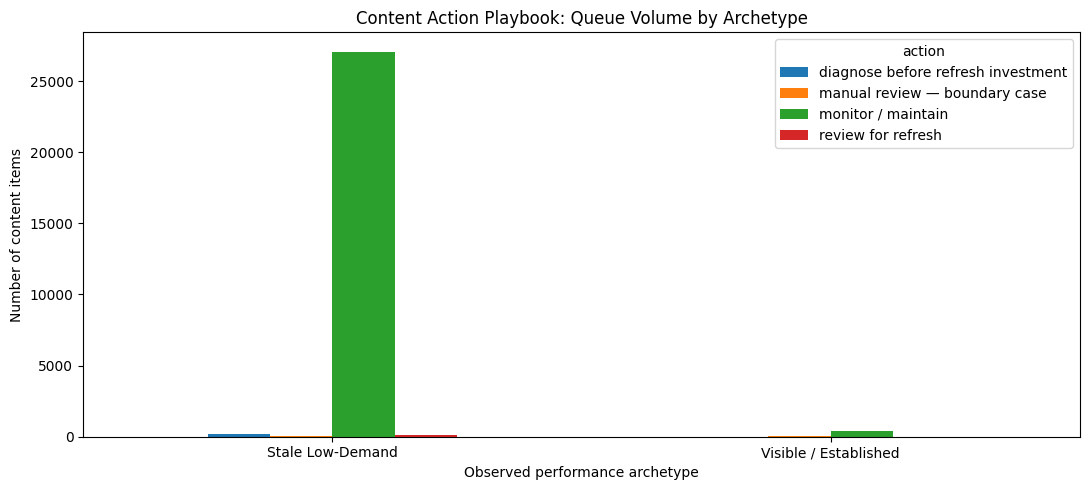

Figure saved to:
/content/work/figures/w07_action_queue_by_archetype.png


In [11]:
# Reusable paper figure.

action_summary = pd.crosstab(
    q["archetype"],
    q["action"]
)

ax = action_summary.plot(
    kind="bar",
    figsize=(11, 5)
)

ax.set_title(
    "Content Action Playbook: Queue Volume by Archetype"
)

ax.set_xlabel(
    "Observed performance archetype"
)

ax.set_ylabel(
    "Number of content items"
)

plt.xticks(rotation=0)
plt.tight_layout()

fig_path = (
    FIG_DIR
    / "w07_action_queue_by_archetype.png"
)

plt.savefig(
    fig_path,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(fig_path)

## 5. Exports for the paper

The ranked queue is exported to `work/outputs/`.

The figure is exported to `work/figures/`.

The queue is intentionally regenerated by the notebook rather than committed to git, because the repository's CI leak-guard keeps data files out of version control.

In [12]:
# Export ranked action queue.

queue_path = (
    OUT_DIR
    / "w07_ranked_action_queue.csv"
)

action_queue.to_csv(
    queue_path,
    index=False
)


# Export archetype profile.

profile_path = (
    OUT_DIR
    / "w07_archetype_profile.csv"
)

profile.to_csv(
    profile_path
)


# Export a small JSON receipt for the paper.

summary = {
    "snapshot_month": SNAPSHOT_MONTH,

    "rows": int(len(q)),

    "clients": int(
        q["client_hash_id"].nunique()
    ),

    "n_clusters": 2,

    "full_snapshot_silhouette": round(
        float(full_silhouette),
        4
    ),

    "w06_grouped_validation_silhouette": 0.6875,

    "w06_validation_client_overlap": 0,

    "thresholds": {
        "stale_days": 90,
        "very_stale_days": 180,
        "meaningful_impressions": 100,
        "high_visibility_impressions": 1000,
    },

    "actions": {
        str(k): int(v)
        for k, v in q["action"]
            .value_counts()
            .items()
    },

    "archetypes": {
        str(k): int(v)
        for k, v in q["archetype"]
            .value_counts()
            .items()
    },

    "claim_boundary": (
        "The queue is decision support based on observed "
        "performance/freshness patterns. It does not establish "
        "causal refresh uplift."
    ),
}

summary_path = (
    OUT_DIR
    / "w07_playbook_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=2
    )


print("Exports created:")
print(" ", queue_path)
print(" ", profile_path)
print(" ", summary_path)
print(" ", fig_path)

Exports created:
  /content/work/outputs/w07_ranked_action_queue.csv
  /content/work/outputs/w07_archetype_profile.csv
  /content/work/outputs/w07_playbook_summary.json
  /content/work/figures/w07_action_queue_by_archetype.png


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.